# Microbial signal in viromes

This notebook documents bacterial reference genomes detected in the 36 viromes and how predicted prophage regions were accounted for.

A bacterial reference genome is reported when at least 10% of its bases are covered in one or more samples. For these genomes, the notebook reports taxonomy, geNomad-predicted prophage regions, and mapping before and after masking those regions.

## Settings

Read the mapping and strain-reference coverage tables, add taxonomy and geNomad-predicted prophage regions, compare unmasked and masked strain-reference mapping, and make the coverage-ranked strain heatmap.

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

VIRAL_FRACTION_DIR = Path('/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION')
VIRAL_WORLD_DIR = VIRAL_FRACTION_DIR.parent
BACTERIAL_FRACTION_DIR = VIRAL_WORLD_DIR / 'BACTERIAL_FRACTION'
FIGURES_TABLES_DIR = VIRAL_FRACTION_DIR / 'FIGURES_AND_TABLES'
MICROBIAL_GENOMES_DIR = BACTERIAL_FRACTION_DIR / 'MICROBIAL_GENOMES_PHYLLOVIR'

SAMPLES_36 = [
    'vFL', 'vOL', 'vF23',
    'vN1', 'vN2', 'vN3',
    'vZ1', 'vZ2', 'vZ3',
    'vF1A', 'vF2A', 'vF3A',
    'vF1B', 'vF2B', 'vF3B',
    'vF1C', 'vF2C', 'vF3C',
    'vO1A', 'vO2A', 'vO3A',
    'vO1B', 'vO2B', 'vO3B',
    'vO1C', 'vO2C', 'vO3C',
    'vS1B', 'vS2B', 'vS3B',
    'vS1C', 'vS2C', 'vS3C',
    'vNWd', 'vSWd', 'vSEd',
]
MIN_DETECTED_GENOME_BREADTH = 0.10

MAPPING_TABLE_PATH = FIGURES_TABLES_DIR / 'final_mapping_table_36_samples.csv'
QC_READ_COUNTS_PATH = FIGURES_TABLES_DIR / '01_qc_read_counts_paired.tot.csv'
MAPPING_REFERENCES_DIR = VIRAL_FRACTION_DIR / '06_MAPPING' / 'REFERENCES'
STRAIN_REFERENCE_COVERAGE_PATH = FIGURES_TABLES_DIR / 'strain_reference_genomes_covered_gt10.csv'
STRAIN_CONTIG_METADATA_PATH = (
    MICROBIAL_GENOMES_DIR / 'strains_in_microbial_fraction_2018.seqtk_comp.with_source.tsv'
)
PROPHAGE_REGIONS_PATH = (
    MICROBIAL_GENOMES_DIR / 'strains_in_microbial_fraction_2018_geNomad_virus_masked_regions.tsv'
)

OUTPUT_DIR = FIGURES_TABLES_DIR / 'SUPPLEMENTARY' / '08_microbial_signal_in_viromes'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
outputs = {
    'sample_manifest': OUTPUT_DIR / '08_main_samples.csv',
    'mapping': OUTPUT_DIR / '08_final_mapping_percentage_summary_36_samples.csv',
    'detected_genomes': OUTPUT_DIR / '08_detected_bacterial_reference_genomes_breadth10.csv',
    'taxonomy': OUTPUT_DIR / '08_detected_bacterial_taxonomy_summary.csv',
    'detected_genome_summary': OUTPUT_DIR / '08_detected_bacterial_reference_genome_summary.csv',
    'strain_mapping_masking': OUTPUT_DIR / '08_strain_mapping_before_after_prophage_masking.csv',
    'strain_mapping_masking_summary': OUTPUT_DIR / '08_strain_mapping_before_after_prophage_masking_summary.csv',
    'heatmap': OUTPUT_DIR / '08_species_coverage_ranked_rpkm_heatmap.svg',
    'heatmap_row_metadata': OUTPUT_DIR / '08_species_coverage_ranked_row_metadata.csv',
    'heatmap_rpkm_matrix': OUTPUT_DIR / '08_species_coverage_ranked_rpkm_matrix.csv',
    'heatmap_breadth_matrix': OUTPUT_DIR / '08_species_coverage_ranked_genome_coverage_matrix.csv',
    'heatmap_selected_genome_matrix': OUTPUT_DIR / '08_species_coverage_ranked_selected_genome_matrix.csv',
    'heatmap_selected_strain_matrix': OUTPUT_DIR / '08_species_coverage_ranked_selected_strain_matrix.csv',
    'heatmap_check': OUTPUT_DIR / '08_heatmap_check.csv',
}
outputs


{'sample_manifest': PosixPath('/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_main_samples.csv'),
 'mapping': PosixPath('/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_final_mapping_percentage_summary_36_samples.csv'),
 'detected_genomes': PosixPath('/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_detected_bacterial_reference_genomes_breadth10.csv'),
 'taxonomy': PosixPath('/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_detected_bacterial_taxonomy_summary.csv'),
 'detected_genome_summary': PosixPath('/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_detected_bacterial_reference_genome_summary.csv'),
 'strain_mapping_masking': PosixPath('/home/lmf/PhylloVir/VIRA

# Main samples


In [8]:
main_samples = pd.DataFrame({
    'sample': SAMPLES_36,
    'sample_order': range(1, len(SAMPLES_36) + 1),
    'included_in_main_36_samples': True,
})
main_samples.to_csv(outputs['sample_manifest'], index=False)
display(main_samples)


,sample,sample_order,included_in_main_36_samples
0,vFL,1,True
1,vOL,2,True
2,vF23,3,True
3,vN1,4,True
4,vN2,5,True
5,vN3,6,True
6,vZ1,7,True
7,vZ2,8,True
8,vZ3,9,True
9,vF1A,10,True


# Final mapping percentage summary

The table below keeps the same order and values as the mapping statistics notebook.
Percentages use the same read-count denominator.


In [9]:
mapping_source = pd.read_csv(MAPPING_TABLE_PATH)
mapping_source['sample'] = mapping_source['sample'].astype(str).str.strip()
missing_samples = sorted(set(SAMPLES_36) - set(mapping_source['sample']))
if missing_samples:
    raise ValueError(f'Mapping table is missing samples: {missing_samples}')
duplicate_samples = sorted(
    mapping_source.loc[mapping_source['sample'].duplicated(), 'sample'].unique()
)
if duplicate_samples:
    raise ValueError(f'Mapping table has duplicate sample rows: {duplicate_samples}')
sample_order = {sample: index for index, sample in enumerate(SAMPLES_36)}
mapping_36 = (
    mapping_source.loc[mapping_source['sample'].isin(SAMPLES_36)]
    .assign(sample_order=lambda frame: frame['sample'].map(sample_order))
    .sort_values('sample_order')
    .drop(columns='sample_order')
    .reset_index(drop=True)
)
if len(mapping_36) != len(SAMPLES_36):
    raise ValueError(f'Expected {len(SAMPLES_36)} main samples, found {len(mapping_36)}')
mapping_36.to_csv(outputs['mapping'], index=False)


# Summary rows are for display only; the saved mapping table stays at 36 samples.
mapping_summary = mapping_36.copy()
summary_rows = pd.DataFrame({
    'sample': ['mean', 'min', 'max', 'std'],
    **{
        column: [
            mapping_36[column].mean(),
            mapping_36[column].min(),
            mapping_36[column].max(),
            mapping_36[column].std(),
        ]
        for column in mapping_36.select_dtypes(include='number').columns
    },
})
mapping_summary = pd.concat([mapping_summary, summary_rows], ignore_index=True).round(1)
display(mapping_summary)


,sample,Read count,% assembled,% viral,% clustered,% filtered,% active,% masked strains
0,vFL,27740533.0,82.8,79.8,89.8,85.2,74.7,3.7
1,vOL,23548868.0,78.8,76.8,86.6,79.7,68.2,1.2
2,vF23,1838773.0,92.3,92.2,90.4,87.4,86.7,0.1
3,vN1,28405527.0,90.1,77.8,91.4,89.8,89.3,1.8
4,vN2,3735702.0,70.3,68.3,81.2,78.7,75.6,6.9
5,vN3,4277329.0,43.1,41.8,45.9,40.5,34.5,42.2
6,vZ1,3245703.0,61.5,59.7,66.8,62.3,58.1,13.4
7,vZ2,6852406.0,73.9,69.8,81.9,79.3,76.6,8.1
8,vZ3,2414911.0,65.9,63.4,64.9,60.9,57.0,16.0
9,vF1A,49809416.0,78.0,73.9,92.4,86.4,84.5,2.3


## Strain-reference mapping before and after prophage masking

Reads were mapped to the strain-reference genomes before and after masking geNomad-predicted viral regions. The difference is the fraction of clean reads that no longer maps after those regions are masked. It measures the possible contribution of predicted prophage regions, but it does not prove that every lost read originated from a dormant integrated prophage.

In [10]:
# Use the same clean-read denominator as the final mapping percentage summary.
qc_read_counts = pd.read_csv(QC_READ_COUNTS_PATH, index_col=0)
clean_read_counts = (
    qc_read_counts[["sample", "bbduk"]]
    .drop_duplicates("sample")
    .assign(bbduk=lambda frame: pd.to_numeric(frame["bbduk"], errors="coerce"))
    .set_index("sample")["bbduk"]
)

def mapped_pairs_from_flagstats(path):
    for line in Path(path).read_text().splitlines():
        if " primary mapped" in line:
            return int(line.split()[0]) / 2
    raise ValueError(f"Could not find primary mapped reads in: {path}")

strain_mapping_rows = []
for sample in SAMPLES_36:
    unmasked_path = (
        MAPPING_REFERENCES_DIR
        / f"bowtie2_flagstats_filtered_strains_in_microbial_fraction_2018_{sample}.tot.txt"
    )
    masked_path = (
        MAPPING_REFERENCES_DIR
        / f"bowtie2_flagstats_filtered_strains_in_microbial_fraction_2018_geNomad_virus_masked_{sample}.tot.txt"
    )
    if not unmasked_path.exists() or not masked_path.exists():
        raise FileNotFoundError(
            f"Missing strain-reference flagstats for {sample}: "
            f"{unmasked_path} or {masked_path}"
        )

    clean_reads = clean_read_counts.get(sample, np.nan)
    if pd.isna(clean_reads) or clean_reads <= 0:
        raise ValueError(f"Missing clean-read count for {sample}")

    unmasked_percent = 100 * mapped_pairs_from_flagstats(unmasked_path) / clean_reads
    masked_percent = 100 * mapped_pairs_from_flagstats(masked_path) / clean_reads
    strain_mapping_rows.append(
        {
            "sample": sample,
            "% unmasked strain references": unmasked_percent,
            "% masked strain references": masked_percent,
            "% reads lost after prophage masking": unmasked_percent - masked_percent,
        }
    )

strain_mapping_before_after_masking = pd.DataFrame(strain_mapping_rows)
strain_mapping_before_after_masking.to_csv(
    outputs["strain_mapping_masking"],
    index=False,
)

strain_mapping_summary = pd.DataFrame(
    {
        "summary": ["mean", "min", "max", "std"],
        "% unmasked strain references": [
            strain_mapping_before_after_masking["% unmasked strain references"].mean(),
            strain_mapping_before_after_masking["% unmasked strain references"].min(),
            strain_mapping_before_after_masking["% unmasked strain references"].max(),
            strain_mapping_before_after_masking["% unmasked strain references"].std(),
        ],
        "% masked strain references": [
            strain_mapping_before_after_masking["% masked strain references"].mean(),
            strain_mapping_before_after_masking["% masked strain references"].min(),
            strain_mapping_before_after_masking["% masked strain references"].max(),
            strain_mapping_before_after_masking["% masked strain references"].std(),
        ],
        "% reads lost after prophage masking": [
            strain_mapping_before_after_masking["% reads lost after prophage masking"].mean(),
            strain_mapping_before_after_masking["% reads lost after prophage masking"].min(),
            strain_mapping_before_after_masking["% reads lost after prophage masking"].max(),
            strain_mapping_before_after_masking["% reads lost after prophage masking"].std(),
        ],
    }
).round(1)
strain_mapping_summary.to_csv(
    outputs["strain_mapping_masking_summary"],
    index=False,
)

display(strain_mapping_before_after_masking.round(1))
display(strain_mapping_summary)


,sample,% unmasked strain references,% masked strain references,% reads lost after prophage masking
0,vFL,26.9,3.7,23.3
1,vOL,6.0,1.2,4.7
2,vF23,0.9,0.1,0.8
3,vN1,82.5,1.8,80.7
4,vN2,70.5,6.9,63.6
5,vN3,65.0,42.2,22.8
6,vZ1,42.5,13.4,29.1
7,vZ2,57.4,8.1,49.3
8,vZ3,57.6,16.0,41.5
9,vF1A,84.9,2.3,82.6


,summary,% unmasked strain references,% masked strain references,% reads lost after prophage masking
0,mean,47.9,24.1,23.8
1,min,0.5,0.1,0.1
2,max,96.3,95.2,82.6
3,std,29.2,27.8,24.2


## Detected bacterial reference genomes, taxonomy, and predicted prophages

Each row is a bacterial reference genome that reaches at least 10% breadth in one or more of the 36 samples. The table records the taxonomic assignment, the samples in which it is detected, and whether geNomad identified one or more predicted prophage regions.

In [11]:
strain_coverage = pd.read_csv(STRAIN_REFERENCE_COVERAGE_PATH)
strain_coverage['sample'] = strain_coverage['sample'].astype(str).str.replace('_T$', '', regex=True)
strain_coverage = strain_coverage.loc[strain_coverage['sample'].isin(SAMPLES_36)].copy()
detected_coverage = strain_coverage.loc[
    strain_coverage['genome_covered_fraction'] >= MIN_DETECTED_GENOME_BREADTH
].copy()
if detected_coverage.empty:
    raise ValueError('No strain-reference genomes meet the 10% genome-coverage threshold.')

taxonomy_columns = [
    column for column in [
        'taxid', 'superkingdom', 'kingdom', 'phylum', 'class', 'order', 'family',
        'genus', 'species', 'strain', 'genome_size',
    ] if column in detected_coverage.columns
]
genome_aggregations = {
    'n_samples_detected': ('sample', 'nunique'),
    'max_genome_breadth': ('genome_covered_fraction', 'max'),
    'median_genome_breadth': ('genome_covered_fraction', 'median'),
    'max_genome_breadth_percent': ('genome_covered_percentage', 'max'),
    'max_rpkm': ('max_rpkm', 'max'),
    'total_mapped_reads': ('read_count', 'sum'),
    'max_pct_clean_reads': ('pct_of_clean_reads', 'max'),
    'max_pct_strain_reference_reads': ('pct_of_strain_reference_mapped_reads', 'max'),
    'genome_length': ('genome_length', 'max'),
}
for column in taxonomy_columns:
    genome_aggregations[column] = (column, 'first')

detected_before_prophage_annotation = (
    detected_coverage.groupby('genome', as_index=False)
    .agg(**genome_aggregations)
    .sort_values(
        ['n_samples_detected', 'max_genome_breadth', 'max_rpkm'],
        ascending=False,
    )
    .reset_index(drop=True)
)

strain_contig_columns = [
    'target_seq', 'sequence_length', 'A', 'C', 'G', 'T', '#2', '#3', '#4',
    '#CpG', '#tv', '#ts', '#CpG-ts', 'genome',
]
strain_contigs = pd.read_csv(
    STRAIN_CONTIG_METADATA_PATH,
    sep='	',
    header=None,
    names=strain_contig_columns,
    usecols=[0, 1, 13],
)
strain_contigs['target_seq'] = strain_contigs['target_seq'].astype(str).str.strip()
strain_contigs['genome'] = strain_contigs['genome'].astype(str).str.strip()
strain_contigs = strain_contigs.drop_duplicates('target_seq')

prophage_regions = pd.read_csv(PROPHAGE_REGIONS_PATH, sep='	')
prophage_regions['target_seq'] = prophage_regions['target_seq'].astype(str).str.strip()
prophage_regions = prophage_regions.merge(
    strain_contigs[['target_seq', 'genome']],
    on='target_seq',
    how='left',
)
if prophage_regions['genome'].isna().any():
    missing_contigs = prophage_regions.loc[
        prophage_regions['genome'].isna(), 'target_seq'
    ].head(5).tolist()
    raise ValueError(f'Could not assign geNomad regions to strain genomes: {missing_contigs}')

prophage_summary = (
    prophage_regions.groupby('genome', as_index=False)
    .agg(
        n_predicted_prophage_regions=('target_seq', 'size'),
        predicted_prophage_bp=('predicted_region_length', 'sum'),
        max_prophage_virus_score=('virus_score', 'max'),
        total_prophage_hallmarks=('n_hallmarks', 'sum'),
    )
)
detected_genomes = detected_before_prophage_annotation.merge(
    prophage_summary,
    on='genome',
    how='left',
)
for column in [
    'n_predicted_prophage_regions',
    'predicted_prophage_bp',
    'total_prophage_hallmarks',
]:
    detected_genomes[column] = detected_genomes[column].fillna(0).astype(int)
detected_genomes['has_predicted_prophage'] = detected_genomes[
    'n_predicted_prophage_regions'
].gt(0)
detected_genomes['predicted_prophage_fraction'] = (
    detected_genomes['predicted_prophage_bp']
    / detected_genomes['genome_length'].replace(0, np.nan)
)
detected_genomes.to_csv(outputs['detected_genomes'], index=False)

taxonomy_summary = (
    detected_genomes.groupby(['phylum', 'genus'], dropna=False, as_index=False)
    .agg(
        n_detected_reference_genomes=('genome', 'nunique'),
        total_sample_detections=('n_samples_detected', 'sum'),
        genomes_with_predicted_prophage=('has_predicted_prophage', 'sum'),
        max_breadth_percent=('max_genome_breadth_percent', 'max'),
    )
    .sort_values(
        ['total_sample_detections', 'n_detected_reference_genomes'],
        ascending=False,
    )
)
taxonomy_summary.to_csv(outputs['taxonomy'], index=False)

detected_genome_summary = pd.DataFrame(
    [
        {
            "metric": "Detected bacterial reference genomes (>=10% breadth)",
            "value": detected_genomes["genome"].nunique(),
        },
        {
            "metric": "Samples with at least one detected bacterial reference genome",
            "value": detected_coverage["sample"].nunique(),
        },
        {
            "metric": "Detected bacterial genera",
            "value": detected_genomes["genus"].dropna().nunique(),
        },
        {
            "metric": "Detected bacterial species",
            "value": detected_genomes["species"].dropna().nunique(),
        },
        {
            "metric": "Detected genomes with >=1 geNomad-predicted prophage region",
            "value": int(detected_genomes["has_predicted_prophage"].sum()),
        },
        {
            "metric": "Detected genomes with >=1 geNomad-predicted prophage region (%)",
            "value": round(
                100 * detected_genomes["has_predicted_prophage"].mean(),
                1,
            ),
        },
    ]
)
detected_genome_summary.to_csv(outputs["detected_genome_summary"], index=False)

display(detected_genome_summary)

display(detected_genomes)
display(taxonomy_summary.head(30))


,metric,value
0,Detected bacterial reference genomes (>=10% br...,374.0
1,Samples with at least one detected bacterial r...,33.0
2,Detected bacterial genera,21.0
3,Detected bacterial species,137.0
4,Detected genomes with >=1 geNomad-predicted pr...,362.0
5,Detected genomes with >=1 geNomad-predicted pr...,96.8


,genome,n_samples_detected,max_genome_breadth,median_genome_breadth,max_genome_breadth_percent,max_rpkm,total_mapped_reads,max_pct_clean_reads,max_pct_strain_reference_reads,genome_length,...,genus,species,strain,genome_size,n_predicted_prophage_regions,predicted_prophage_bp,max_prophage_virus_score,total_prophage_hallmarks,has_predicted_prophage,predicted_prophage_fraction
0,Erwinia_aphidicola_B09_9,20,0.948192,0.776150,94.819228,1141.628800,55417915,17.373126,19.709820,4701288,...,Erwinia,Erwinia aphidicola,Erwinia aphidicola B09_9,4701288,6,241062,0.9755,101,True,0.051276
1,GCF_024462615.1_ASM2446261v1,15,0.972778,0.386995,97.277755,15.471131,558900,0.160808,2.497146,2503816,...,Cutibacterium,Cutibacterium acnes,Cutibacterium acnes DFI.6.115,2578628,211,74812,0.9547,0,True,0.029879
2,GCF_963878835.1_ena-yuan-GCF_003122445.1,15,0.843292,0.589184,84.329211,45.280050,1230115,0.317550,9.572413,2265757,...,Candidatus Williamhamiltonella,Candidatus Williamhamiltonella defendens,Candidatus Williamhamiltonella defendens na,2265757,3,138177,0.9602,55,True,0.060985
3,GCF_902859575.1_HaCicuneomaculata_2628_v1.0,14,0.952264,0.700867,95.226402,517.799700,1221624,0.441231,17.520228,1998723,...,Candidatus Williamhamiltonella,Candidatus Williamhamiltonella defendens,Candidatus Williamhamiltonella defendens HaCic...,2110590,24,135596,0.9670,55,True,0.067841
4,GCF_002777235.1_ASM277723v1,14,0.832290,0.734878,83.229020,123.223740,1623768,0.480487,26.773209,2272646,...,Candidatus Williamhamiltonella,Candidatus Williamhamiltonella defendens,Candidatus Williamhamiltonella defendens ZA17,2272646,6,245036,0.9581,88,True,0.107820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,GCF_002563895.1_ASM256389v1,1,0.303743,0.303743,30.374302,0.210996,38137,0.034232,0.133173,6311648,...,Pseudomonas,Pseudomonas lurida,Pseudomonas lurida LMG 21995,6311648,1,18739,0.9555,12,True,0.002969
370,GCF_014842725.1_ASM1484272v1,1,0.302587,0.302587,30.258721,1.277528,20670,0.022326,0.025124,4776233,...,Pseudomonas,Pseudomonas sp. CFBP 13602,Pseudomonas sp. CFBP 13602 CFBP13602,4779684,4,51317,0.9731,13,True,0.010744
371,GCF_900006605.1_PSEFL294_LIB5413,1,0.301516,0.301516,30.151612,0.527381,35698,0.038559,0.043390,6653611,...,Pseudomonas,Pseudomonas sp. 58 R 3,Pseudomonas sp. 58 R 3 na,6664133,18,75794,0.9596,34,True,0.011391
372,GCF_014268265.1_ASM1426826v1,1,0.301124,0.301124,30.112431,0.969991,36324,0.032605,0.126842,6244192,...,Pseudomonas,Pseudomonas lurida,Pseudomonas lurida PGSB 8273,6249690,13,80549,0.9688,27,True,0.012900


,phylum,genus,n_detected_reference_genomes,total_sample_detections,genomes_with_predicted_prophage,max_breadth_percent
14,Pseudomonadota,Pantoea,179,1001,177,97.765103
10,Pseudomonadota,Erwinia,35,239,35,96.687630
15,Pseudomonadota,Pseudomonas,87,221,87,96.732707
9,Pseudomonadota,Candidatus Williamhamiltonella,7,83,7,95.226402
16,Pseudomonadota,Rahnella,15,65,15,96.274618
2,Actinomycetota,Frigoribacterium,13,21,9,64.197577
1,Actinomycetota,Cutibacterium,2,19,1,97.277755
18,Pseudomonadota,Sphingomonas,13,15,12,80.157489
5,Actinomycetota,Sanguibacter,3,6,1,93.808517
17,Pseudomonadota,Rickettsiella,1,6,0,97.182439


# Species coverage-ranked strain heatmap

This recreates the final heatmap from the mapping notebook. Species are selected by
aggregate genome breadth, while cell color remains `log10(RPKM + 1)`. Within each
species and sample, the displayed reference is the strain with the greatest genome
breadth; ties use RPKM, read count, then genome ID. Rows are grouped by genus, with
genera ordered by their total breadth signal and white divider lines between them.


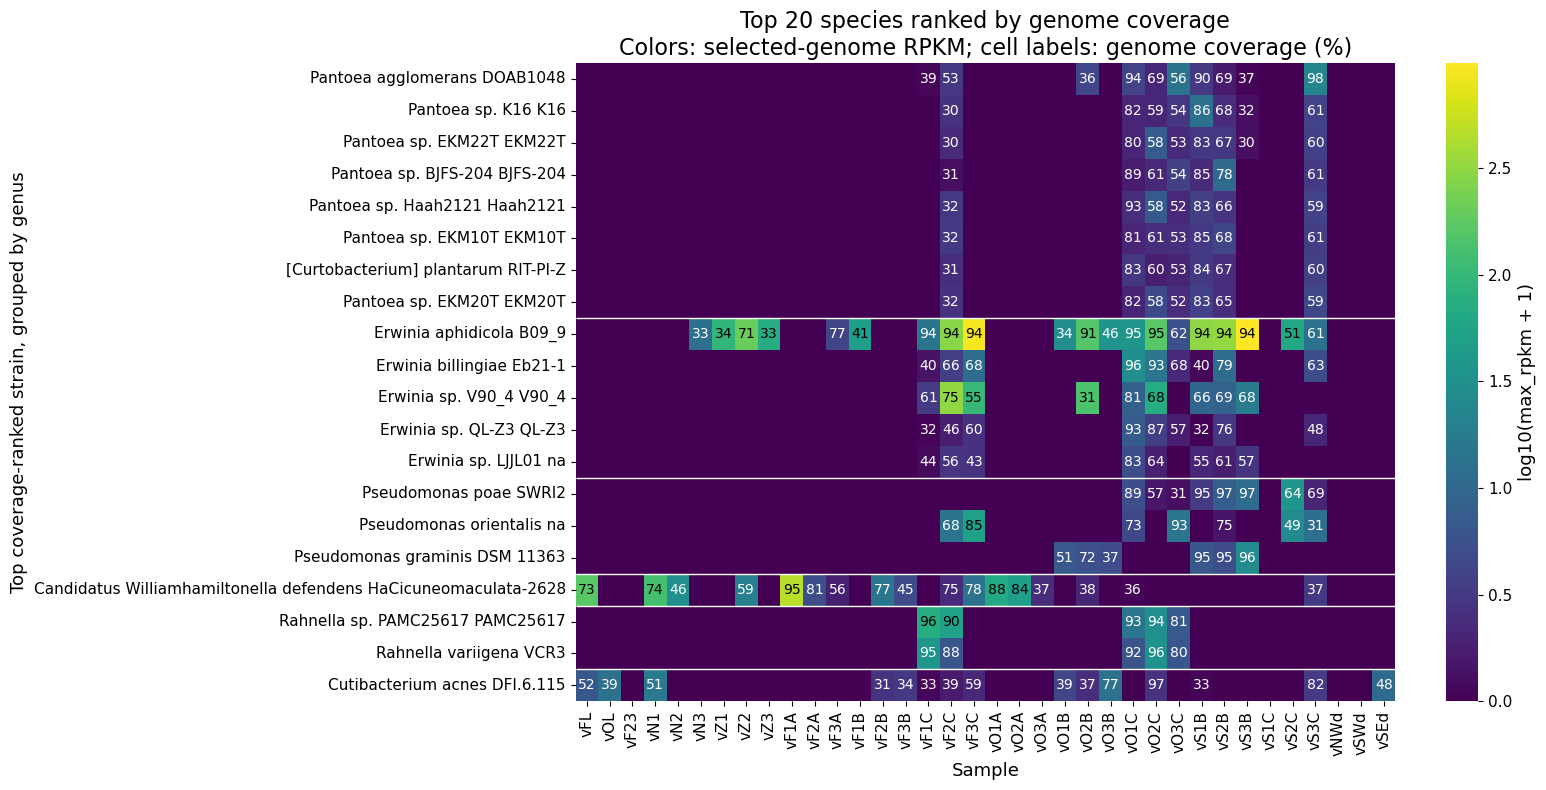

Saved coverage-ranked row metadata: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_species_coverage_ranked_row_metadata.csv
Saved coverage-ranked RPKM matrix: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_species_coverage_ranked_rpkm_matrix.csv
Saved coverage-ranked breadth matrix: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_species_coverage_ranked_genome_coverage_matrix.csv
Saved selected-genome matrix: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_species_coverage_ranked_selected_genome_matrix.csv
Saved selected-strain matrix: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_species_coverage_ranked_selected_strain_matrix.csv
Saved heatmap SVG: /home/lm

In [12]:
TOP_N_SPECIES = 20
COVERAGE_COLUMN = 'genome_covered_percentage'
RPKM_COLOR_COLUMN = 'max_rpkm'
PLOT_LOG10_RPKM = True
HEATMAP_XTICK_FONT_SIZE = 11
HEATMAP_YTICK_FONT_SIZE = 11
HEATMAP_AXIS_LABEL_FONT_SIZE = 13
HEATMAP_TITLE_FONT_SIZE = 16
HEATMAP_ANNOT_FONT_SIZE = 10

def first_nonempty(values):
    values = pd.Series(values).dropna().astype(str)
    values = values[values.str.strip().ne('') & values.str.lower().ne('nan')]
    return values.iloc[0] if len(values) else np.nan

def clean_taxonomic_group(values, fallback):
    group = values.astype('string')
    group = group.mask(group.str.strip().eq(''), pd.NA)
    group = group.mask(group.str.lower().eq('nan'), pd.NA)
    return group.fillna(fallback.astype(str))

def add_taxonomic_groups(frame):
    species_group = clean_taxonomic_group(frame['species'], frame['genome'])
    fallback_genus = species_group.astype(str).str.split().str[0]
    genus_group = clean_taxonomic_group(frame['genus'], fallback_genus)
    return frame.assign(
        species_group=species_group.astype(str),
        genus_group=genus_group.astype(str),
    )

def matrix_with_row_metadata(matrix, row_metadata=None):
    output = matrix.reset_index().rename(columns={'species_group': 'species'})
    if row_metadata is not None:
        metadata_columns = [
            'species', 'row_label', 'genus', 'genus_total_coverage',
            'species_total_coverage', 'species_max_coverage',
            'species_mean_coverage_detected', 'top_coverage_genome',
            'top_coverage_strain', 'top_strain_max_coverage',
            'top_strain_total_coverage', 'n_samples_detected',
            'species_total_max_rpkm', 'species_total_mapped_reads',
        ]
        metadata_columns = [
            column for column in metadata_columns if column in row_metadata.columns
        ]
        output = output.merge(row_metadata[metadata_columns], on='species', how='left')
        sample_columns = [column for column in output.columns if column in SAMPLES_36]
        output = output[
            [column for column in metadata_columns if column in output.columns] + sample_columns
        ]
    return output

def coverage_annotation_strings(coverage_matrix, rpkm_matrix):
    coverage_for_labels = coverage_matrix.where(rpkm_matrix > 0)
    return coverage_for_labels.apply(
        lambda column: column.map(
            lambda value: '' if pd.isna(value) else f'{value:.0f}'
        )
    )

strain_source = pd.read_csv(STRAIN_REFERENCE_COVERAGE_PATH)
required_columns = {'sample', 'genome', RPKM_COLOR_COLUMN, COVERAGE_COLUMN, 'read_count'}
if not required_columns.issubset(strain_source.columns):
    raise ValueError(f'Heatmap input is missing columns: {sorted(required_columns - set(strain_source.columns))}')

strain_source = strain_source.copy()
strain_source[RPKM_COLOR_COLUMN] = pd.to_numeric(
    strain_source[RPKM_COLOR_COLUMN], errors='coerce'
).fillna(0)
strain_source[COVERAGE_COLUMN] = pd.to_numeric(
    strain_source[COVERAGE_COLUMN], errors='coerce'
).fillna(0)
strain_source['read_count'] = pd.to_numeric(strain_source['read_count'], errors='coerce').fillna(0)
strain_source = strain_source.loc[strain_source['sample'].isin(SAMPLES_36)].copy()
strain_source = add_taxonomic_groups(strain_source)
if 'strain' not in strain_source.columns:
    strain_source['strain'] = np.nan

# One strain per species/sample: highest breadth, then RPKM, reads, and genome ID.
species_sample_top = (
    strain_source
    .sort_values(
        ['species_group', 'sample', COVERAGE_COLUMN, RPKM_COLOR_COLUMN, 'read_count', 'genome'],
        ascending=[True, True, False, False, False, True],
    )
    .drop_duplicates(['species_group', 'sample'], keep='first')
)

species_signal = (
    species_sample_top
    .groupby(['genus_group', 'species_group'], as_index=False)
    .agg(
        species_total_coverage=(COVERAGE_COLUMN, 'sum'),
        species_max_coverage=(COVERAGE_COLUMN, 'max'),
        species_mean_coverage_detected=(COVERAGE_COLUMN, 'mean'),
        species_total_max_rpkm=(RPKM_COLOR_COLUMN, 'sum'),
        species_total_mapped_reads=('read_count', 'sum'),
        n_samples_detected=('sample', 'nunique'),
    )
)
top_strain_by_coverage = (
    strain_source
    .groupby(['genus_group', 'species_group', 'genome'], as_index=False)
    .agg(
        top_strain_total_coverage=(COVERAGE_COLUMN, 'sum'),
        top_strain_max_coverage=(COVERAGE_COLUMN, 'max'),
        top_strain_total_max_rpkm=(RPKM_COLOR_COLUMN, 'sum'),
        top_strain_mapped_reads=('read_count', 'sum'),
        top_coverage_strain=('strain', first_nonempty),
    )
    .sort_values(
        [
            'species_group', 'top_strain_total_coverage',
            'top_strain_max_coverage', 'top_strain_total_max_rpkm',
            'top_strain_mapped_reads', 'genome',
        ],
        ascending=[True, False, False, False, False, True],
    )
    .drop_duplicates('species_group', keep='first')
    .rename(columns={'genome': 'top_coverage_genome'})
)
heatmap_rows = (
    species_signal
    .merge(
        top_strain_by_coverage[
            [
                'species_group', 'top_coverage_genome', 'top_coverage_strain',
                'top_strain_total_coverage', 'top_strain_max_coverage',
                'top_strain_total_max_rpkm', 'top_strain_mapped_reads',
            ]
        ],
        on='species_group',
        how='left',
    )
    .rename(columns={'species_group': 'species', 'genus_group': 'genus'})
    .sort_values(
        ['species_total_coverage', 'species_max_coverage', 'n_samples_detected', 'species_total_max_rpkm'],
        ascending=False,
    )
    .head(TOP_N_SPECIES)
)
genus_signal = (
    heatmap_rows.groupby('genus', as_index=False)
    .agg(
        genus_total_coverage=('species_total_coverage', 'sum'),
        genus_max_coverage=('species_max_coverage', 'max'),
        n_species_in_heatmap=('species', 'nunique'),
    )
)
heatmap_rows = heatmap_rows.merge(genus_signal, on='genus', how='left')
has_strain_label = (
    heatmap_rows['top_coverage_strain'].notna()
    & heatmap_rows['top_coverage_strain'].astype(str).str.strip().ne('')
    & heatmap_rows['top_coverage_strain'].astype(str).str.lower().ne('nan')
)
heatmap_rows['row_label'] = np.where(
    has_strain_label,
    heatmap_rows['top_coverage_strain'].astype(str),
    heatmap_rows['species'].astype(str),
)
heatmap_rows = (
    heatmap_rows.assign(
        genus_sort=lambda frame: frame['genus'].str.lower(),
        species_sort=lambda frame: frame['species'].str.lower(),
    )
    .sort_values(
        ['genus_total_coverage', 'genus_sort', 'species_total_coverage', 'species_sort'],
        ascending=[False, True, False, True],
    )
    .drop(columns=['genus_sort', 'species_sort'])
    .reset_index(drop=True)
)

ordered_species = heatmap_rows['species'].tolist()
selected_species_sample_rows = species_sample_top.loc[
    species_sample_top['species_group'].isin(ordered_species)
].copy()
species_rpkm_matrix = (
    selected_species_sample_rows
    .pivot_table(
        index='species_group', columns='sample', values=RPKM_COLOR_COLUMN,
        aggfunc='max', fill_value=0,
    )
    .reindex(index=ordered_species)
    .reindex(columns=SAMPLES_36, fill_value=0)
)
species_coverage_matrix = (
    selected_species_sample_rows
    .pivot_table(
        index='species_group', columns='sample', values=COVERAGE_COLUMN, aggfunc='max',
    )
    .reindex(index=ordered_species)
    .reindex(columns=SAMPLES_36)
)
selected_genome_matrix = (
    selected_species_sample_rows
    .pivot_table(
        index='species_group', columns='sample', values='genome', aggfunc=first_nonempty,
    )
    .reindex(index=ordered_species)
    .reindex(columns=SAMPLES_36)
)
selected_strain_matrix = (
    selected_species_sample_rows
    .pivot_table(
        index='species_group', columns='sample', values='strain', aggfunc=first_nonempty,
    )
    .reindex(index=ordered_species)
    .reindex(columns=SAMPLES_36)
)

heatmap_rows.to_csv(outputs['heatmap_row_metadata'], index=False)
matrix_with_row_metadata(species_rpkm_matrix, heatmap_rows).to_csv(
    outputs['heatmap_rpkm_matrix'], index=False
)
matrix_with_row_metadata(species_coverage_matrix.round(0).astype('Int64'), heatmap_rows).to_csv(
    outputs['heatmap_breadth_matrix'], index=False
)
matrix_with_row_metadata(selected_genome_matrix).to_csv(
    outputs['heatmap_selected_genome_matrix'], index=False
)
matrix_with_row_metadata(selected_strain_matrix).to_csv(
    outputs['heatmap_selected_strain_matrix'], index=False
)

row_label_map = heatmap_rows.set_index('species')['row_label'].to_dict()
plot_rpkm_matrix = species_rpkm_matrix.rename(index=row_label_map)
plot_coverage_matrix = species_coverage_matrix.rename(index=row_label_map)
heatmap_values = np.log10(plot_rpkm_matrix + 1) if PLOT_LOG10_RPKM else plot_rpkm_matrix
coverage_annotations = coverage_annotation_strings(plot_coverage_matrix, plot_rpkm_matrix)

fig_height = max(8, 0.28 * len(plot_rpkm_matrix))
fig_width = max(14, 0.45 * len(plot_rpkm_matrix.columns))
fig, axis = plt.subplots(figsize=(fig_width, fig_height))
sns.heatmap(
    heatmap_values,
    cmap='viridis',
    linewidths=0,
    ax=axis,
    annot=coverage_annotations,
    fmt='',
    annot_kws={'fontsize': HEATMAP_ANNOT_FONT_SIZE},
    cbar_kws={'label': 'log10(max_rpkm + 1)'},
)
axis.set_xticks(np.arange(len(plot_rpkm_matrix.columns)) + 0.5)
axis.set_xticklabels(
    plot_rpkm_matrix.columns,
    rotation=90,
    ha='center',
    fontsize=HEATMAP_XTICK_FONT_SIZE,
)
axis.set_yticks(np.arange(len(plot_rpkm_matrix.index)) + 0.5)
axis.set_yticklabels(
    plot_rpkm_matrix.index,
    rotation=0,
    fontsize=HEATMAP_YTICK_FONT_SIZE,
)

genus_order = heatmap_rows.set_index('species').loc[species_rpkm_matrix.index, 'genus']
genus_boundaries = np.where(genus_order.ne(genus_order.shift()).to_numpy()[1:])[0] + 1
for boundary in genus_boundaries:
    axis.hlines(boundary, *axis.get_xlim(), colors='white', linewidth=1)

max_heatmap_value = np.nanmax(heatmap_values.to_numpy()) if heatmap_values.size else 0
for text, value in zip(axis.texts, heatmap_values.to_numpy().ravel()):
    if text.get_text():
        text.set_color(
            'black' if max_heatmap_value and value > max_heatmap_value * 0.55 else 'white'
        )

axis.set_xlabel('Sample', fontsize=HEATMAP_AXIS_LABEL_FONT_SIZE)
axis.set_ylabel(
    'Top coverage-ranked strain, grouped by genus',
    fontsize=HEATMAP_AXIS_LABEL_FONT_SIZE,
)
axis.set_title(
    f'Top {len(plot_rpkm_matrix)} species ranked by genome coverage\n'
    'Colors: selected-genome RPKM; cell labels: genome coverage (%)',
    fontsize=HEATMAP_TITLE_FONT_SIZE,
)
axis.figure.axes[-1].yaxis.label.set_size(HEATMAP_AXIS_LABEL_FONT_SIZE)
axis.figure.axes[-1].tick_params(labelsize=HEATMAP_XTICK_FONT_SIZE)
fig.tight_layout()
fig.savefig(outputs['heatmap'], format='svg', bbox_inches='tight')
plt.show()
plt.close(fig)

print(f'Saved coverage-ranked row metadata: {outputs["heatmap_row_metadata"]}')
print(f'Saved coverage-ranked RPKM matrix: {outputs["heatmap_rpkm_matrix"]}')
print(f'Saved coverage-ranked breadth matrix: {outputs["heatmap_breadth_matrix"]}')
print(f'Saved selected-genome matrix: {outputs["heatmap_selected_genome_matrix"]}')
print(f'Saved selected-strain matrix: {outputs["heatmap_selected_strain_matrix"]}')
print(f'Saved heatmap SVG: {outputs["heatmap"]}')
